In [2]:
!pip install opencv-python

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV Version:",cv2.__version__)
print("NumPy Version:",np.__version__)

OpenCV Version: 4.13.0
NumPy Version: 2.1.3


In [4]:
import os
import pandas as pd

dataset_path="dataset"

files=os.listdir(dataset_path)

df=pd.DataFrame(files,columns=["filename"])

df.head()

,filename
0,100_0_0_20170112213500903.jpg.chip.jpg
1,100_0_0_20170112215240346.jpg.chip.jpg
2,100_1_0_20170110183726390.jpg.chip.jpg
3,100_1_0_20170112213001988.jpg.chip.jpg
4,100_1_0_20170112213303693.jpg.chip.jpg


In [5]:
len(df)

23708

In [6]:
df["age"]=df["filename"].apply(lambda x: int(x.split("_")[0]))
df["gender"]=df["filename"].apply(lambda x: int(x.split("_")[1]))

df.head()

,filename,age,gender
0,100_0_0_20170112213500903.jpg.chip.jpg,100,0
1,100_0_0_20170112215240346.jpg.chip.jpg,100,0
2,100_1_0_20170110183726390.jpg.chip.jpg,100,1
3,100_1_0_20170112213001988.jpg.chip.jpg,100,1
4,100_1_0_20170112213303693.jpg.chip.jpg,100,1


In [7]:
print(df["age"].head())
print(df["gender"].head())

0    100
1    100
2    100
3    100
4    100
Name: age, dtype: int64
0    0
1    0
2    1
3    1
4    1
Name: gender, dtype: int64


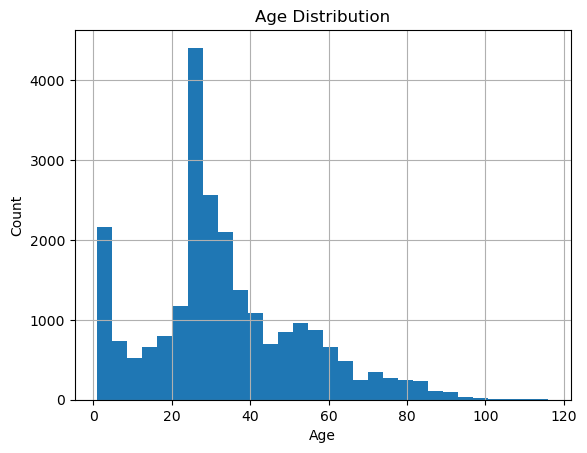

In [8]:
import matplotlib.pyplot as plt

df["age"].hist(bins=30)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

import os
os.makedirs("images",exist_ok=True)
plt.savefig(
    "images/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [9]:
df["gender"].value_counts()

gender
0    12391
1    11317
Name: count, dtype: int64

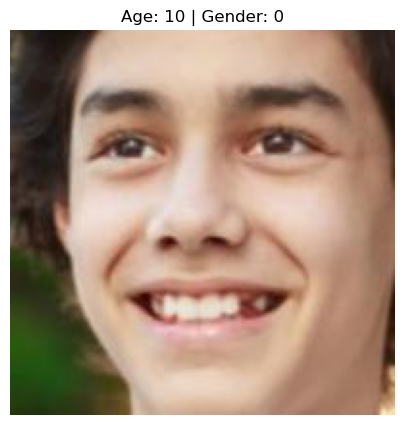

In [10]:
sample=df.iloc[100]
img_path="dataset/"+sample["filename"]
img=cv2.imread(img_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title(
    f"Age: {sample['age']} | Gender: {sample['gender']}"
)
plt.axis("off")
plt.show()

In [11]:
img.shape

(200, 200, 3)

In [12]:
print(img[0,0])
print(img.dtype)

[73 63 53]
uint8


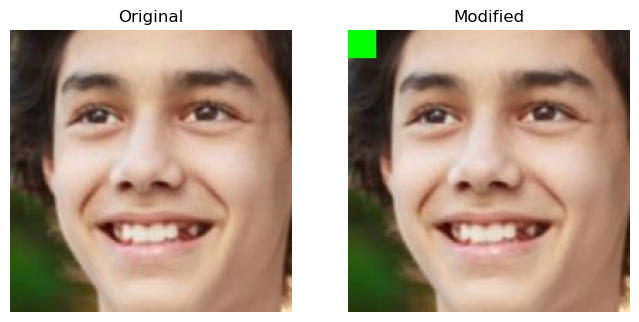

In [13]:
modified=img.copy()

modified[0:20,0:20]=[0,255,0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(modified)
plt.title("Modified")
plt.axis("off")

plt.show()

In [14]:
import os
for file in os.listdir("models"):
    print(file)

age_deploy.prototxt
age_net.caffemodel
gender_deploy.prototxt
gender_net.caffemodel
opencv_face_detector.pbtxt
opencv_face_detector_uint8.pb


In [15]:
faceNet=cv2.dnn.readNet(
    "models/opencv_face_detector_uint8.pb",
    "models/opencv_face_detector.pbtxt"
)

ageNet=cv2.dnn.readNet(
    "models/age_net.caffemodel",
    "models/age_deploy.prototxt"
)

genderNet=cv2.dnn.readNet(
    "models/gender_net.caffemodel",
    "models/gender_deploy.prototxt"
)

print("All models loaded successfully!")

All models loaded successfully!


In [16]:
print(type(faceNet))
print(type(ageNet))
print(type(genderNet))

<class 'cv2.dnn.Net'>
<class 'cv2.dnn.Net'>
<class 'cv2.dnn.Net'>


In [17]:
img = cv2.imread("dataset/" + df.iloc[0]["filename"])

result = img.copy()

blob = cv2.dnn.blobFromImage(
    img,
    1.0,
    (300, 300),
    [104, 117, 123],
    swapRB=False
)

faceNet.setInput(blob)
detections = faceNet.forward()

print("Detections Shape:", detections.shape)

Detections Shape: (1, 1, 200, 7)


In [18]:
print(detections[0,0,0])

[0.         1.         0.99983704 2.0416517  1.982543   2.857638
 3.0063043 ]


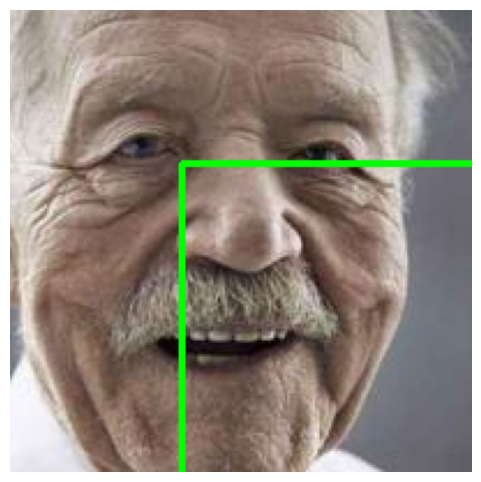

In [19]:
img=cv2.imread("dataset/" + df.iloc[0]["filename"])

h,w=img.shape[:2]

blob=cv2.dnn.blobFromImage(
    img,
    1.0,
    (300,300),
    [104,117,123],
    swapRB=False
)

faceNet.setInput(blob)
detections=faceNet.forward()

for i in range(detections.shape[2]):

    confidence=detections[0,0,i,2]

    if confidence>0.7:

        x1 = int(detections[0,0,i,3] * w)
        y1 = int(detections[0,0,i,4] * h)
        x2 = int(detections[0,0,i,5] * w)
        y2 = int(detections[0,0,i,6] * h)

        cv2.rectangle(
            img,
            (x1,y1),
            (x2,y2),
            (0,255,0),
            2
        )

img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
img=cv2.imread("test.png")
print(img.shape)

(212, 202, 3)


In [22]:
img=cv2.imread("dataset/"+df.iloc[0]["filename"])

face=cv2.resize(img, (227, 227))

print(face.shape)

(227, 227, 3)


In [23]:
genderList=['Male', 'Female']

blob=cv2.dnn.blobFromImage(
    face,
    1.0,
    (227, 227),
    (78.4263377603, 87.7689143744, 114.895847746),
    swapRB=False
)

genderNet.setInput(blob)

genderPreds=genderNet.forward()

print(genderPreds)

[[0.97676176 0.02323825]]


In [25]:
gender=genderList[genderPreds[0].argmax()]

print("Predicted Gender:", gender)

Predicted Gender: Male


In [26]:
ageList=[
    '(0-2)',
    '(4-6)',
    '(8-12)',
    '(15-20)',
    '(25-32)',
    '(38-43)',
    '(48-53)',
    '(60-100)'
]

ageNet.setInput(blob)

agePreds=ageNet.forward()

print(agePreds)

[[9.7158581e-06 2.2700003e-06 1.2955163e-05 8.6674791e-06 8.4302992e-05
  2.6152960e-03 9.9218741e-02 8.9804798e-01]]


In [27]:
age=ageList[agePreds[0].argmax()]

print("Predicted Age:", age)

Predicted Age: (60-100)


In [28]:
def predict_age_gender(image_path):

    img=cv2.imread(image_path)

    face=cv2.resize(img, (227, 227))

    blob=cv2.dnn.blobFromImage(
        face,
        1.0,
        (227, 227),
        (78.4263377603, 87.7689143744, 114.895847746),
        swapRB=False
    )

    genderList=['Male', 'Female']

    ageList=[
        '(0-2)',
        '(4-6)',
        '(8-12)',
        '(15-20)',
        '(25-32)',
        '(38-43)',
        '(48-53)',
        '(60-100)'
    ]

    genderNet.setInput(blob)
    genderPreds=genderNet.forward()

    ageNet.setInput(blob)
    agePreds=ageNet.forward()

    gender=genderList[genderPreds[0].argmax()]
    age=ageList[agePreds[0].argmax()]

    print("Gender:", gender)
    print("Age:", age)

In [29]:
predict_age_gender(
    "dataset/"+df.iloc[0]["filename"]
)

Gender: Male
Age: (60-100)


In [30]:
def predict_age_gender(image_path):

    img=cv2.imread(image_path)

    face=cv2.resize(img, (227, 227))

    blob=cv2.dnn.blobFromImage(
        face,
        1.0,
        (227, 227),
        (78.4263377603, 87.7689143744, 114.895847746),
        swapRB=False
    )

    genderList=['Male', 'Female']

    ageList=[
        '(0-2)',
        '(4-6)',
        '(8-12)',
        '(15-20)',
        '(25-32)',
        '(38-43)',
        '(48-53)',
        '(60-100)'
    ]

    genderNet.setInput(blob)
    genderPreds=genderNet.forward()

    ageNet.setInput(blob)
    agePreds=ageNet.forward()

    gender=genderList[genderPreds[0].argmax()]
    age=ageList[agePreds[0].argmax()]

    return gender, age

In [31]:
gender, age = predict_age_gender(
    "dataset/" + df.iloc[0]["filename"]
)

print(gender)
print(age)

Male
(60-100)


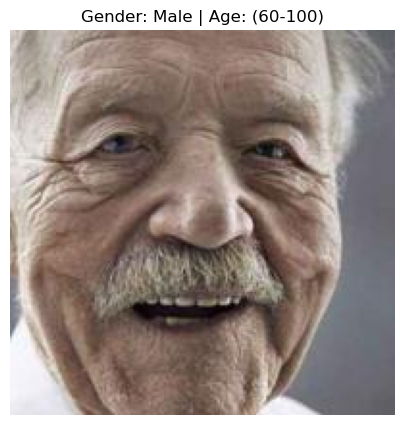

In [32]:
import matplotlib.pyplot as plt

image_path = "dataset/" + df.iloc[0]["filename"]

gender, age = predict_age_gender(image_path)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)

plt.title(
    f"Gender: {gender} | Age: {age}",
    fontsize=12
)

plt.axis("off")
plt.show()

In [35]:
sample_df=df.sample(100,random_state=42)
sample_df

,filename,age,gender
17525,49_1_0_20170104185652921.jpg.chip.jpg,49,1
1147,17_1_0_20170109214200825.jpg.chip.jpg,17,1
1190,17_1_4_20170103201233799.jpg.chip.jpg,17,1
9731,29_0_4_20170103235921692.jpg.chip.jpg,29,0
7387,26_1_2_20170116180208093.jpg.chip.jpg,26,1
...,...,...,...
3711,23_0_0_20170104004006925.jpg.chip.jpg,23,0
6345,26_0_2_20170116181354956.jpg.chip.jpg,26,0
13207,35_0_2_20170116233726860.jpg.chip.jpg,35,0
6864,26_1_0_20170117171447434.jpg.chip.jpg,26,1


In [36]:
for index,row in sample_df.iterrows():

    image_path="dataset/"+row["filename"]

    predicted_gender,predicted_age=predict_age_gender(image_path)

    actual_gender="Male" if row["gender"]==0 else "Female"

    print("-" * 50)
    print("Actual Gender   :",actual_gender)
    print("Predicted Gender:",predicted_gender)

    print("Actual Age      :",row["age"])
    print("Predicted Age   :",predicted_age)

--------------------------------------------------
Actual Gender   : Female
Predicted Gender: Male
Actual Age      : 49
Predicted Age   : (60-100)
--------------------------------------------------
Actual Gender   : Female
Predicted Gender: Female
Actual Age      : 17
Predicted Age   : (8-12)
--------------------------------------------------
Actual Gender   : Female
Predicted Gender: Female
Actual Age      : 17
Predicted Age   : (15-20)
--------------------------------------------------
Actual Gender   : Male
Predicted Gender: Male
Actual Age      : 29
Predicted Age   : (15-20)
--------------------------------------------------
Actual Gender   : Female
Predicted Gender: Female
Actual Age      : 26
Predicted Age   : (25-32)
--------------------------------------------------
Actual Gender   : Male
Predicted Gender: Male
Actual Age      : 41
Predicted Age   : (25-32)
--------------------------------------------------
Actual Gender   : Female
Predicted Gender: Female
Actual Age      : 26


In [38]:
correct=0
total=100

sample_df=df.sample(total, random_state=42)

for _, row in sample_df.iterrows():

    image_path="dataset/"+row["filename"]

    predicted_gender, _=predict_age_gender(image_path)

    actual_gender="Male" if row["gender"]==0 else "Female"

    if predicted_gender==actual_gender:
        correct+=1

accuracy=(correct / total)*100

print(f"Gender Accuracy: {accuracy:.2f}%")

Gender Accuracy: 84.00%


In [39]:
df[["filename","gender"]]

,filename,gender
0,100_0_0_20170112213500903.jpg.chip.jpg,0
1,100_0_0_20170112215240346.jpg.chip.jpg,0
2,100_1_0_20170110183726390.jpg.chip.jpg,1
3,100_1_0_20170112213001988.jpg.chip.jpg,1
4,100_1_0_20170112213303693.jpg.chip.jpg,1
...,...,...
23703,9_1_3_20161220222856346.jpg.chip.jpg,1
23704,9_1_3_20170104222949455.jpg.chip.jpg,1
23705,9_1_4_20170103200637399.jpg.chip.jpg,1
23706,9_1_4_20170103200814791.jpg.chip.jpg,1


In [40]:
gender_df=df[["filename", "gender"]].copy()

gender_df.head()

,filename,gender
0,100_0_0_20170112213500903.jpg.chip.jpg,0
1,100_0_0_20170112215240346.jpg.chip.jpg,0
2,100_1_0_20170110183726390.jpg.chip.jpg,1
3,100_1_0_20170112213001988.jpg.chip.jpg,1
4,100_1_0_20170112213303693.jpg.chip.jpg,1


In [41]:
print(gender_df["gender"].value_counts())

gender
0    12391
1    11317
Name: count, dtype: int64


In [53]:
small_df=gender_df.sample(10000, random_state=42)

print(len(small_df))
small_df.head()

10000


,filename,gender
17525,49_1_0_20170104185652921.jpg.chip.jpg,1
1147,17_1_0_20170109214200825.jpg.chip.jpg,1
1190,17_1_4_20170103201233799.jpg.chip.jpg,1
9731,29_0_4_20170103235921692.jpg.chip.jpg,0
7387,26_1_2_20170116180208093.jpg.chip.jpg,1


In [54]:
import cv2
import numpy as np

X = []
y = []

for _, row in small_df.iterrows():

    image_path = "dataset/" + row["filename"]

    img = cv2.imread(image_path)

    if img is None:
        continue

    img = cv2.resize(img, (64, 64))

    X.append(img)
    y.append(row["gender"])

print("Done!")

Done!


In [55]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(10000, 64, 64, 3)
(10000,)


In [56]:
X=X / 255.0

print(X.min())
print(X.max())

0.0
1.0


In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 64, 64, 3)
(2000, 64, 64, 3)


In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    ),
    
    MaxPooling2D((2,2)),
    
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    
    MaxPooling2D((2,2)),
    
    Flatten(),
    
    Dense(
        128,
        activation='relu'
    ),
    
    Dense(
        1,
        activation='sigmoid'
    )
])

model.summary()

C:\Users\Adrija\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [61]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.9753 - loss: 0.0709 - val_accuracy: 0.8835 - val_loss: 0.3617
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.9778 - loss: 0.0624 - val_accuracy: 0.8810 - val_loss: 0.4331
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.9821 - loss: 0.0542 - val_accuracy: 0.8830 - val_loss: 0.4010
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.9869 - loss: 0.0392 - val_accuracy: 0.8775 - val_loss: 0.4399
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.9879 - loss: 0.0399 - val_accuracy: 0.8790 - val_loss: 0.4628
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.9786 - loss: 0.0597 - val_accuracy: 0.8855 - val_loss: 0.4501
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - accuracy: 0.9898 - loss: 0.0307 - val_accuracy: 0.8815 - val_loss: 0.4487
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9916 - loss: 0.0296 - 

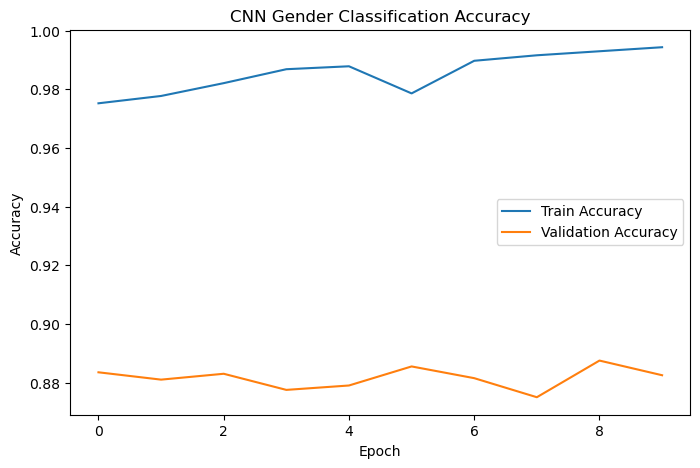

In [62]:
import os
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Gender Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    "images/cnn_accuracy.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

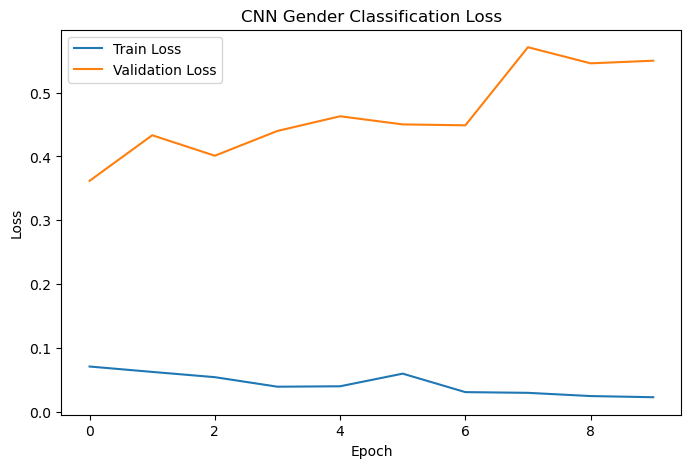

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Gender Classification Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "images/cnn_loss.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [65]:
model.save("models/gender_cnn.keras")

In [66]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8825 - loss: 0.5499
Test Accuracy: 88.25%


In [67]:
from tensorflow.keras.models import load_model
import cv2
import numpy as np

model = load_model("models/gender_cnn.keras")

def predict_gender(image_path):

    img = cv2.imread(image_path)

    img = cv2.resize(img, (64, 64))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)

    probability = prediction[0][0]

    if probability > 0.5:
        gender = "Female"
    else:
        gender = "Male"

    confidence = max(probability, 1 - probability)

    return gender, confidence

In [76]:
image_path = "dataset/" + df.iloc[99]["filename"]

gender, confidence = predict_gender(image_path)

print("Predicted Gender:", gender)
print("Confidence:", confidence)

Predicted Gender: Male
Confidence: 0.99995893


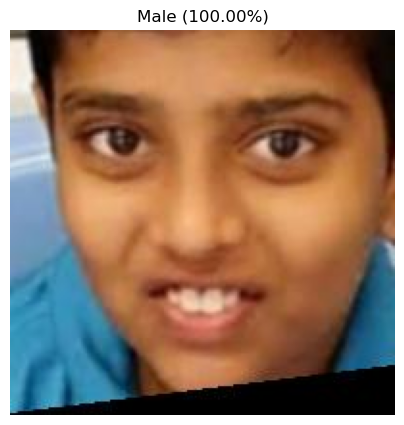

In [77]:
import matplotlib.pyplot as plt

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))
plt.imshow(img)

plt.title(
    f"{gender} ({confidence:.2%})"
)

plt.axis("off")
plt.show()